<a href="https://colab.research.google.com/github/rayeluchi/predicting-crop-yield-ML/blob/main/RayeCopyReport.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Final Project Report -- Title**

> by Ella, Raye, & Emma



# Introduction

"Problem and motivation"

# Experiment

## Notebook Configuration

### Google Drive Connection

In [ ]:
from google.colab import drive
import sys

# Mount Google Drive
drive.mount('/content/drive')

# Get the absolute path of the current folder
abspath_curr = '/content/drive/Shareddrives/MacLearning_FinalProject/'

# Get the absolute path of the utilities folder
abspath_util = '/content/drive/Shareddrives/MacLearning_FinalProject/Utilities/'

Mounted at /content/drive


### Library Imports

In [ ]:
# warnings
import warnings
warnings.filterwarnings('ignore')

# matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

# TensorFlow
import tensorflow as tf
from tensorflow import keras

# Data Libraries
import numpy as np
import pandas as pd
import seaborn as sns
from pandas.api.types import is_datetime64_any_dtype as is_datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from scipy.stats import pearsonr

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from scipy.stats import uniform, loguniform

In [ ]:
# Change working directory to the absolute path of the shallow utilities folder
%cd $abspath_util

# Import the shallow utitilities
%run pmlm_utilities_shallow.ipynb
%run pmlm_utilities_deep.ipynb
%run pmlm_models_shallow.ipynb

/content/drive/Shareddrives/MacLearning_FinalProject/Utilities


### Random seed

In [ ]:
# The random seed
random_seed = 42

# Set random seed in tensorflow
tf.random.set_seed(random_seed)

# Set random seed in numpy
np.random.seed(random_seed)

## Exploratory Data Analysis

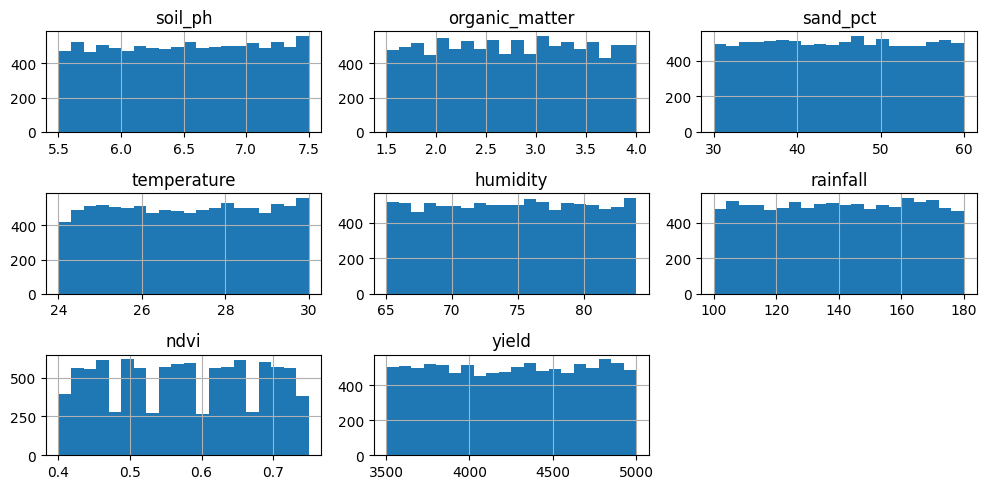

In [ ]:
# sns.pairplot(data = df_train.sample(500), height=1.0)
df_train = pd.read_csv(f"{abspath_curr}Data/train.csv").copy(deep=True)
features = ['soil_ph', 'organic_matter', 'sand_pct', 'temperature', 'humidity', 'rainfall', 'ndvi', 'yield']
df_train[features].hist(bins=20, figsize=(10, 5))
plt.tight_layout()
plt.show()

In [ ]:
corr = df_train[features].corr()
print('Pearson correlation coefficient matrix for each independent variable:')
corr

Pearson correlation coefficient matrix for each independent variable:


,soil_ph,organic_matter,sand_pct,temperature,humidity,rainfall,ndvi,yield
soil_ph,1.000000,-0.016595,-0.024560,-0.005485,-0.006664,-0.005365,-0.009469,0.007098
organic_matter,-0.016595,1.000000,0.000227,0.001544,-0.012198,0.007677,-0.007599,0.002207
sand_pct,-0.024560,0.000227,1.000000,0.008607,-0.004474,0.023181,-0.011729,-0.003933
temperature,-0.005485,0.001544,0.008607,1.000000,-0.013643,-0.015184,-0.009789,-0.014943
humidity,-0.006664,-0.012198,-0.004474,-0.013643,1.000000,0.003410,0.016542,0.001252
rainfall,-0.005365,0.007677,0.023181,-0.015184,0.003410,1.000000,-0.027723,0.016959
ndvi,-0.009469,-0.007599,-0.011729,-0.009789,0.016542,-0.027723,1.000000,-0.001619
yield,0.007098,0.002207,-0.003933,-0.014943,0.001252,0.016959,-0.001619,1.000000


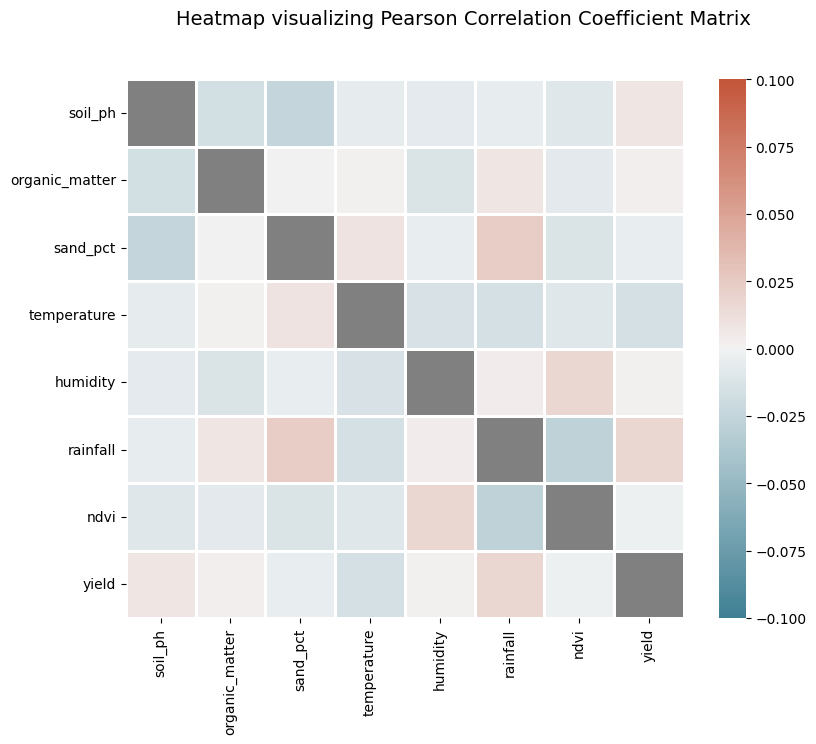

In [ ]:
masking = np.zeros_like(corr, dtype = np.bool)
np.fill_diagonal(masking, val = True)

figure, axis = plt.subplots(figsize = (9, 7))
c_map = sns.diverging_palette(220, 20, as_cmap=True)
c_map.set_bad('grey')

sns.heatmap(corr, mask = masking, cmap = c_map, vmin = -0.1, vmax = 0.1, center = 0, linewidths = 1)
figure.suptitle('Heatmap visualizing Pearson Correlation Coefficient Matrix', fontsize = 14)
axis.tick_params(axis = 'both', which = 'major', labelsize = 10)

## Data Preprocessing

In [ ]:
'''Split the data'''
# load the data
df_train = pd.read_csv(f"{abspath_curr}Data/train.csv").copy(deep=True)
df_test = pd.read_csv(f"{abspath_curr}Data/test.csv").copy(deep=True)

# define the target
target = 'yield'

# split the data
df_train, df_val = train_test_split(df_train, train_size=0.8, random_state=random_seed)
df_train, df_val = df_train.reset_index(drop=True), df_val.reset_index(drop=True)


'''Handle uncommon vars'''
# check for vars
df_common_var = common_var_checker(df_train, df_val, df_test, target)

# create uncommon drop function
def drop_uncommon(df, df_common_var):
  uncommon_feature = np.setdiff1d(df.columns, df_common_var['common var'])
  df = df.drop(columns=uncommon_feature)
  return df

# drop vars if found
df_train, df_val, df_test = drop_uncommon(df_train, df_common_var), drop_uncommon(df_val, df_common_var), drop_uncommon(df_test, df_common_var)


'''Handle ID vars'''
# check for ID and remove if found
df_id = id_checker(pd.concat([df_train, df_val, df_test], sort=False))
df_train.drop(columns=np.intersect1d(df_id.columns, df_train.columns), inplace=True)
df_val.drop(columns=np.intersect1d(df_id.columns, df_val.columns), inplace=True)
df_test.drop(columns=np.intersect1d(df_id.columns, df_test.columns), inplace=True)


'''Handling Datetime -- unnecessary'''


'''Handle missing data'''
# check data for nan
df = pd.concat([df_train, df_val, df_test], sort=False)
df_nan = nan_checker(df)

# get info on missing vars
df_miss = df_nan[df_nan['dtype'] == 'float64'].reset_index(drop=True)

# separate the data
df_train = df.iloc[:df_train.shape[0], :]
df_val = df.iloc[df_train.shape[0]:df_train.shape[0] + df_val.shape[0], :]
df_test = df.iloc[df_train.shape[0] + df_val.shape[0]:, :]

# impute vars if missing
if df_miss.shape[0] > 0:
  si = SimpleImputer(missing_values=np.nan, strategy='mean')
  df_train[df_miss['var']] = si.fit_transform(df_train[df_miss['var']])
  df_val[df_miss['var']] = si.transform(df_val[df_miss['var']])
  df_test[df_miss['var']] = si.transform(df_test[df_miss['var']])


'''Encode the data -- unnecessary'''


'''Scale the data'''
# feature matrix
X_train, X_val, X_test = df_train[np.setdiff1d(df_train.columns, [target])].values, df_val[np.setdiff1d(df_val.columns, [target])].values, df_test[np.setdiff1d(df_test.columns, [target])].values

# target vector
y_train, y_val, y_test = df_train[target].values, df_val[target].values, df_test[target].values

## Hyperparameter Tuning

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

import sklearn.metrics
sk_mse = sklearn.metrics.mean_squared_error

from sklearn.model_selection import GridSearchCV, KFold

In [ ]:
# Baseline models (no tuning yet)
baseline_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        random_state=random_seed,
        n_estimators=300,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=random_seed
    ),
    "XGBoost": XGBRegressor(
        objective="reg:squarederror",
        random_state=random_seed,
        tree_method="hist"
    ),
    "Neural Network": MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        learning_rate_init=0.001,
        max_iter=300,
        random_state=random_seed
    )
}

baseline_results = []

for name, model in baseline_models.items():
    print(f"Fitting baseline {name}...")
    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)
    rmse_val = ((y_val - y_val_pred) ** 2).mean() ** 0.5
    baseline_results.append({"model": name, "val_rmse": rmse_val})

baseline_results_df = (
    pd.DataFrame(baseline_results)
      .sort_values("val_rmse")
      .reset_index(drop=True)
)

baseline_results_df

Fitting baseline Linear Regression...
Fitting baseline Random Forest...
Fitting baseline Gradient Boosting...
Fitting baseline XGBoost...
Fitting baseline Neural Network...


,model,val_rmse
0,Linear Regression,435.250468
1,Gradient Boosting,436.163493
2,Random Forest,442.902709
3,Neural Network,465.450965
4,XGBoost,467.853902


In [ ]:
best_model_name = baseline_results_df.loc[0, "model"]
print("Best baseline model:", best_model_name)

Best baseline model: Linear Regression


In [ ]:
# Pick the best NON-LINEAR model (ignore Linear Regression)
nonlin_candidates = ["Random Forest", "Gradient Boosting", "XGBoost", "Neural Network"]

nonlin_results = baseline_results_df[
    baseline_results_df["model"].isin(nonlin_candidates)
].reset_index(drop=True)

best_nonlin_model = nonlin_results.loc[0, "model"]
print("Best non-linear model (for tuning):", best_nonlin_model)

Best non-linear model (for tuning): Gradient Boosting


In [ ]:
baseline_mean = y_train.mean()
y_val_mean_pred = np.full_like(y_val, baseline_mean)
baseline_rmse = ((y_val - y_val_mean_pred) ** 2).mean() ** 0.5
print("Baseline (predict mean) RMSE:", baseline_rmse)

Baseline (predict mean) RMSE: 435.3251829629841


In [ ]:
param_dists = {
    "Random Forest": {
        "n_estimators": [200, 400, 600],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2],
        "max_features": ["sqrt", "log2"]
    },
    "Gradient Boosting": {
        "n_estimators": [300, 600],
        "learning_rate": [0.01, 0.02, 0.05],
        "max_depth": [3, 4],
        "subsample": [0.7, 0.9, 1.0]
    },
    "XGBoost": {
        "n_estimators": [300, 600],
        "learning_rate": [0.01, 0.05],
        "max_depth": [3, 5],
        "subsample": [0.7, 0.9],
        "colsample_bytree": [0.7, 1.0],
        "reg_lambda": [1, 5]
    },
    "Neural Network": {
        "hidden_layer_sizes": [(64,), (64, 32)],
        "learning_rate_init": [0.001, 0.0005],
        "alpha": [0.0001, 0.001],
        "batch_size": [32, 64]
    }
}

print("Best non-linear model (from baseline):", best_nonlin_model)

# --------------------------------------
# 2. Pick base_model + param_dist
#    (skip Linear Regression completely)
# --------------------------------------
if best_nonlin_model == "Random Forest":
    base_model = RandomForestRegressor(random_state=random_seed, n_jobs=-1)

elif best_nonlin_model == "Gradient Boosting":
    base_model = GradientBoostingRegressor(random_state=random_seed)

elif best_nonlin_model == "XGBoost":
    base_model = XGBRegressor(
        objective="reg:squarederror",
        random_state=random_seed,
        tree_method="hist"
    )

elif best_nonlin_model == "Neural Network":
    base_model = MLPRegressor(max_iter=500, random_state=random_seed)

else:
    raise ValueError(f"Unexpected non-linear model name: {best_nonlin_model}")

param_dist = param_dists[best_nonlin_model]

# --------------------------------------
# 3. RandomizedSearchCV (faster than full grid)
# --------------------------------------
cv = KFold(n_splits=3, shuffle=True, random_state=random_seed)

random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=15,                         # keeps it fast but non-trivial
    scoring="neg_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    random_state=random_seed,
    return_train_score=True
)

print(f"\nRunning hyperparameter tuning for: {best_nonlin_model}")
random_search.fit(X_train, y_train)

tuned_model = random_search.best_estimator_
best_params = random_search.best_params_
best_cv_rmse = np.sqrt(-random_search.best_score_)

print("\nBest hyperparameters:", best_params)
print(f"Best CV RMSE ({best_nonlin_model}): {best_cv_rmse:.4f}")

# --------------------------------------
# 4. Evaluate tuned model on validation set
# --------------------------------------
y_val_pred_tuned = tuned_model.predict(X_val)
val_rmse_tuned = ((y_val - y_val_pred_tuned) ** 2).mean() ** 0.5

print(f"Validation RMSE (tuned {best_nonlin_model}): {val_rmse_tuned:.4f}")

tuned_results_df = pd.DataFrame([{
    "model": f"{best_nonlin_model} (tuned)",
    "cv_rmse": best_cv_rmse,
    "val_rmse": val_rmse_tuned,
    "params": best_params
}])

tuned_results_df

Best non-linear model (from baseline): Gradient Boosting

Running hyperparameter tuning for: Gradient Boosting
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best hyperparameters: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.01}
Best CV RMSE (Gradient Boosting): 438.1657
Validation RMSE (tuned Gradient Boosting): 435.2348


,model,cv_rmse,val_rmse,params
0,Gradient Boosting (tuned),438.165739,435.234848,"{'subsample': 0.7, 'n_estimators': 300, 'max_d..."


# Model Selection

In [ ]:
best_nonlin_model = "Gradient Boosting"   # Or "XGBoost" or "Gradient Boosting"
print("Selected model for tuning:", best_nonlin_model)

Selected model for tuning: Gradient Boosting


In [ ]:
# Predict validation yields using the tuned model
y_val_pred_tuned = tuned_model.predict(X_val)

# Compute tuned RMSE
tuned_rmse = np.sqrt(((y_val - y_val_pred_tuned) ** 2).mean())
print("Validation RMSE (tuned model):", tuned_rmse)


Validation RMSE (tuned model): 435.23484832061246


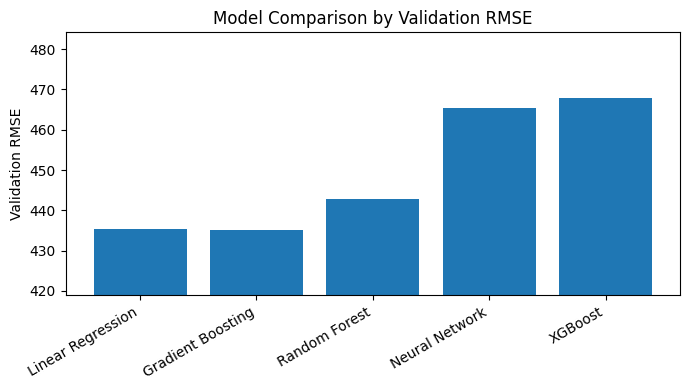

In [ ]:
rmse_df = baseline_results_df.copy()
rmse_df.loc[rmse_df["model"] == "Gradient Boosting", "val_rmse"] = tuned_rmse

plt.figure(figsize=(7, 4))
plt.bar(rmse_df["model"], rmse_df["val_rmse"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Validation RMSE")
plt.title("Model Comparison by Validation RMSE")

# Smart zoom
rmse_range = rmse_df["val_rmse"].max() - rmse_df["val_rmse"].min()
padding = rmse_range * 0.5
plt.ylim(rmse_df["val_rmse"].min() - padding, rmse_df["val_rmse"].max() + padding)

plt.tight_layout()
plt.show()



### Linear Regression performed the best even after Gradient Boosting was tuned. The Gradient Boost model had an RMSE of 435.34 and the Linear Regression had an RMSE of 435.25. This difference is less than 0.1 RMSE, which tells us that the data is mostly linear and there is no meaningful non-linear structure to observe. Therefore, we will not tune the Gradient Boosting model any further but rather continue the feature analysis with the **Linear Regression model. **

# Feature Analysis

In [ ]:
from sklearn.linear_model import LinearRegression

# Refit on full training data (train + val combined)
X_full = np.vstack([X_train, X_val])
y_full = np.concatenate([y_train, y_val])

lin_model = LinearRegression()
lin_model.fit(X_full, y_full)

coeffs = lin_model.coef_
features = df_train.drop(columns=['yield']).columns


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_full_scaled = scaler.fit_transform(X_full)

lin_model_scaled = LinearRegression()
lin_model_scaled.fit(X_full_scaled, y_full)

coeffs_scaled = lin_model_scaled.coef_


In [ ]:
import statsmodels.api as sm
import pandas as pd

# Make a DataFrame with your actual feature names
X_full_df = pd.DataFrame(X_full_scaled, columns=features)

# Add constant for intercept
X_full_df = sm.add_constant(X_full_df)

# Fit model
ols = sm.OLS(y_full, X_full_df).fit()

# Print summary with real feature names
print(ols.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.8250
Date:                Mon, 08 Dec 2025   Prob (F-statistic):              0.566
Time:                        21:59:23   Log-Likelihood:                -74975.
No. Observations:               10000   AIC:                         1.500e+05
Df Residuals:                    9992   BIC:                         1.500e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           4251.9764      4.366    973.

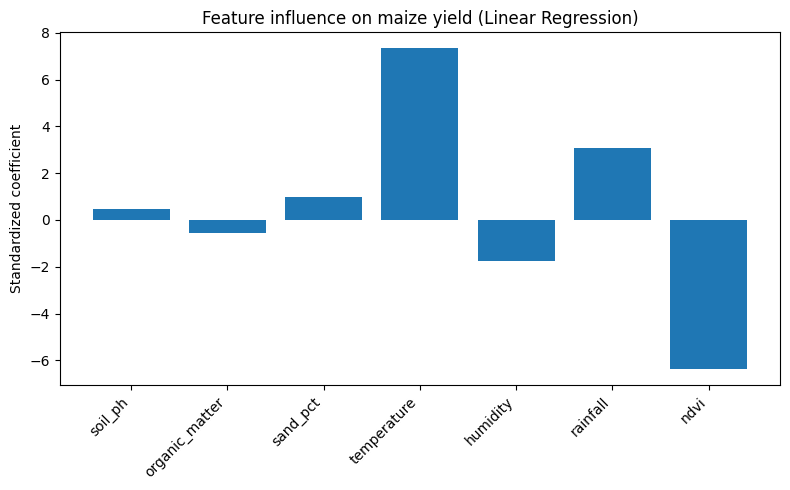

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(features, coeffs_scaled)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Standardized coefficient")
plt.title("Feature influence on maize yield (Linear Regression)")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# Get feature importances from tuned Gradient Boosting model
gb_importances = tuned_model.feature_importances_

# Simple heuristic threshold:
# Mark a feature as "important" if its importance is above the average importance
threshold = gb_importances.mean()

gb_imp_df = pd.DataFrame({
    "feature": features,
    "importance": gb_importances
})

gb_imp_df["important"] = gb_imp_df["importance"] > threshold

# Sort by importance
gb_imp_df = gb_imp_df.sort_values("importance", ascending=False).reset_index(drop=True)

gb_imp_df


,feature,importance,important
0,temperature,0.212001,True
1,rainfall,0.210412,True
2,humidity,0.153116,True
3,sand_pct,0.148400,True
4,ndvi,0.105785,False
5,organic_matter,0.097993,False
6,soil_ph,0.072292,False


In [ ]:
threshold

np.float64(0.14285714285714282)

## Outputs

## Results Discussion

# Conclusions